In [1]:
from google.colab import files

uploaded = files.upload()


Saving kaggle.json to kaggle (2).json


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle competitions download -c ieee-fraud-detection
!unzip -q ieee-fraud-detection.zip


ieee-fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace test_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace test_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


# **Análise de Detecção de Fraudes com Redes Neurais LSTM**

**Autores:** Enzo Boccia, Pedro Faria
**Data:** 20 de Setembro de 2025

---

## **1. Introdução**

Este notebook apresenta um projeto completo de *Data Science* focado na detecção de transações fraudulentas, utilizando o conhecido e desafiador dataset da competição **IEEE-CIS Fraud Detection**. O objetivo principal é construir, treinar e avaliar um modelo de *deep learning*, especificamente uma Rede Neural de Memória de Curto e Longo Prazo (LSTM), para classificar transações como legítimas ou fraudulentas.

Ao longo deste relatório, o leitor encontrará um pipeline de ponta a ponta, que inclui as seguintes etapas:

*   **Análise Exploratória dos Dados (EDA):** Uma investigação inicial para entender as características, distribuições e o severo desbalanceamento do dataset.
*   **Engenharia de Features:** Transformação de colunas categóricas em formato numérico para maximizar o poder preditivo do modelo.
*   **Pré-processamento e Gerenciamento de Memória:** Soluções para os desafios técnicos do dataset, como o tratamento de valores ausentes, a normalização de dados e a implementação de um gerador de dados (`DataGenerator`) para lidar com o grande volume de informações.
*   **Modelagem e Treinamento:** Definição da arquitetura LSTM e o processo de treinamento, incluindo estratégias para combater o desbalanceamento de classes.
*   **Avaliação e Análise Crítica:** Uma análise detalhada do desempenho do modelo, utilizando métricas como Recall e AUC-ROC, seguida de um diagnóstico sobre suas limitações e propostas para melhorias futuras.

Este trabalho busca não apenas cumprir os requisitos técnicos da tarefa, mas também demonstrar um processo de análise crítica e iterativa, fundamental para a resolução de problemas complexos no mundo real.


In [4]:
# --- 1. IMPORTAÇÃO DAS BIBLIOTECAS ---

# Manipulação de dados e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow e Keras para o modelo LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import Sequence

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


In [5]:
# --- 2. CARREGAMENTO E UNIFICAÇÃO DOS DADOS ---

try:
    # Carregando os datasets de treino
    train_transaction = pd.read_csv('train_transaction.csv')
    train_identity = pd.read_csv('train_identity.csv')

    # Unindo os datasets pela coluna 'TransactionID'
    df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

    print(f"Datasets unificados com sucesso. O dataset completo possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
    del train_transaction, train_identity # Libera memória

except FileNotFoundError:
    print("Erro: Arquivos 'train_transaction.csv' ou 'train_identity.csv' não encontrados.")
    print("Certifique-se de que os arquivos estão na pasta /content/ do seu ambiente Colab.")


Datasets unificados com sucesso. O dataset completo possui 590540 linhas e 434 colunas.


In [6]:
# --- 3. ENGENHARIA DE FEATURES (TRANSFORMANDO COLUNAS CATEGÓRICAS) ---

if 'df' in locals():
    print("Iniciando Engenharia de Features...")

    # Preenche valores ausentes em colunas de texto com 'missing'
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].fillna('missing')

    # Lida com colunas de alta cardinalidade usando Frequency Encoding
    high_cardinality_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() > 15]
    print("\n1. Aplicando Frequency Encoding em:", high_cardinality_cols)
    for col in high_cardinality_cols:
        freq_map = df[col].value_counts(normalize=True).to_dict()
        df[col] = df[col].map(freq_map)

    # Lida com colunas de baixa cardinalidade usando One-Hot Encoding
    low_cardinality_cols = [col for col in df.select_dtypes(include=['object']).columns]
    if low_cardinality_cols:
        print("\n2. Aplicando One-Hot Encoding em:", low_cardinality_cols)
        df = pd.get_dummies(df, columns=low_cardinality_cols, dummy_na=False) # dummy_na=False pois já tratamos NaNs

    print("\nEngenharia de features concluída. O dataset foi enriquecido e está pronto para o pré-processamento.")
else:
    print("Erro: DataFrame 'df' não encontrado.")


Iniciando Engenharia de Features...

1. Aplicando Frequency Encoding em: ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']

2. Aplicando One-Hot Encoding em: ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']

Engenharia de features concluída. O dataset foi enriquecido e está pronto para o pré-processamento.


In [7]:
# --- 4. PREPARAÇÃO DOS DADOS E CRIAÇÃO DO GERADOR ---

if 'df' in locals():
    # 1. AMOSTRAGEM PARA GERENCIAMENTO DE MEMÓRIA
    print(f"\nTamanho do dataset completo: {df.shape[0]} linhas, {df.shape[1]} colunas.")
    df_sample = df.sample(frac=0.2, random_state=42)
    print(f"Usando uma amostra de {len(df_sample)} linhas para o treinamento.")
    del df # Libera memória do dataframe completo

    # 2. OTIMIZAÇÃO E PRÉ-PROCESSAMENTO
    for col in df_sample.select_dtypes(include=['float64']).columns:
        df_sample[col] = df_sample[col].astype(np.float32)
    for col in df_sample.select_dtypes(include=['int64']).columns:
        df_sample[col] = df_sample[col].astype(np.int32)

    numeric_cols = [col for col in df_sample.columns if df_sample[col].dtype != 'object' and col != 'isFraud' and col != 'TransactionID']

    df_sample[numeric_cols] = df_sample[numeric_cols].fillna(df_sample[numeric_cols].median())
    scaler = StandardScaler()
    df_sample[numeric_cols] = scaler.fit_transform(df_sample[numeric_cols])
    print("\nPré-processamento (scaling e fillna) concluído.")

    # 3. CRIAÇÃO DO GERADOR DE DADOS
    train_df, val_df = train_test_split(df_sample, test_size=0.2, random_state=42, stratify=df_sample['isFraud'])
    del df_sample # Libera memória

    class DataGenerator(Sequence):
        def __init__(self, dataframe, features_cols, label_col, batch_size=64, seq_length=10, shuffle=True):
            self.df = dataframe.copy().reset_index(drop=True)
            self.features_cols = features_cols
            self.label_col = label_col
            self.batch_size = batch_size
            self.seq_length = seq_length
            self.shuffle = shuffle
            self.indexes = np.arange(self.seq_length, len(self.df))
            self.on_epoch_end()
        def __len__(self):
            return int(np.floor(len(self.indexes) / self.batch_size))
        def __getitem__(self, index):
            start_idx_pos = index * self.batch_size
            end_idx_pos = (index + 1) * self.batch_size
            batch_indexes_pos = self.indexes[start_idx_pos:end_idx_pos]
            X, y = self.__data_generation(batch_indexes_pos)
            return X, y
        def on_epoch_end(self):
            if self.shuffle:
                np.random.shuffle(self.indexes)
        def __data_generation(self, batch_indexes_pos):
            X = np.empty((len(batch_indexes_pos), self.seq_length, len(self.features_cols)))
            y = np.empty((len(batch_indexes_pos)), dtype=int)
            for i, pos_idx in enumerate(batch_indexes_pos):
                start_seq_pos = pos_idx - self.seq_length
                end_seq_pos = pos_idx
                X[i,] = self.df.iloc[start_seq_pos:end_seq_pos][self.features_cols].values
                y[i] = self.df.iloc[pos_idx][self.label_col]
            return X, y

    sequence_length = 10
    batch_size = 64
    train_generator = DataGenerator(dataframe=train_df, features_cols=numeric_cols, label_col='isFraud', batch_size=batch_size, seq_length=sequence_length)
    val_generator = DataGenerator(dataframe=val_df, features_cols=numeric_cols, label_col='isFraud', batch_size=batch_size, seq_length=sequence_length)
    X_test, y_test = val_generator[0]

    print("\nGeradores de treino e validação criados com sucesso!")
else:
    print("Erro: DataFrame 'df' não encontrado.")



Tamanho do dataset completo: 590540 linhas, 495 colunas.
Usando uma amostra de 118108 linhas para o treinamento.

Pré-processamento (scaling e fillna) concluído.

Geradores de treino e validação criados com sucesso!


In [8]:
# --- 5. DEFINIÇÃO DA ARQUITETURA DO MODELO ---

input_shape = (sequence_length, len(numeric_cols))

model = Sequential([
    LSTM(64, input_shape=input_shape, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │       142,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,297 (606.63 KB)

 Trainable params: 155,297 (606.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# --- 6. TREINAMENTO DO MODELO OTIMIZADO ---

if 'model' in locals() and 'train_generator' in locals():
    # Calcula os pesos para balancear as classes e combater o desbalanceamento
    labels_for_weight = train_df['isFraud'].values
    classes = np.unique(labels_for_weight)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels_for_weight)
    class_weights = dict(zip(classes, weights))
    print("Pesos de Classe para o Treinamento:", class_weights)

    print("\nIniciando o treinamento do modelo...")

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        class_weight=class_weights, # Aplica os pesos para focar na classe de fraude
        verbose=1
    )

    print("\nTreinamento concluído.")
else:
    print("Erro: Modelo ou gerador de treino não encontrado.")


Pesos de Classe para o Treinamento: {np.int32(0): np.float64(0.5186295174109691), np.int32(1): np.float64(13.91956393635828)}

Iniciando o treinamento do modelo...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4876 - loss: 0.7003

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1476/1476 ━━━━━━━━━━━━━━━━━━━━ 119s 78ms/step - accuracy: 0.4876 - loss: 0.7003 - val_accuracy: 0.5621 - val_loss: 0.6890
Epoch 2/15
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 115s 78ms/step - accuracy: 0.5610 - loss: 0.6820 - val_accuracy: 0.0587 - val_loss: 0.7920
Epoch 3/15
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 117s 79ms/step - accuracy: 0.4429 - loss: 0.6929 - val_accuracy: 0.8388 - val_loss: 0.6224
Epoch 4/15
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 118s 80ms/step - accuracy: 0.5866 - loss: 0.6743 - val_accuracy: 0.5805 - val_loss: 0.6734
Epoch 5/15
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 140s 78ms/step - accuracy: 0.5815 - loss: 0.6659 - val_accuracy: 0.6202 - val_loss: 0.6412
Epoch 6/15
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 115s 78ms/step - accuracy: 0.6235 - loss: 0.6320 - val_accuracy: 0.5154 - val_loss: 0.6917
Epoch 7/15
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 115s 78ms/step - accuracy: 0.6467 - loss: 0.5998 - val_accuracy: 0.6708 - val_loss: 0.5823
Epoch 8/15
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 117s 79ms/step - accuracy: 0.6949 - lo

Avaliando o modelo treinado...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 

--- Resultados da Avaliação no Conjunto de Teste ---
Precisão: 0.0714
Recall: 0.5000
F1-Score: 0.1250
AUC-ROC: 0.4839


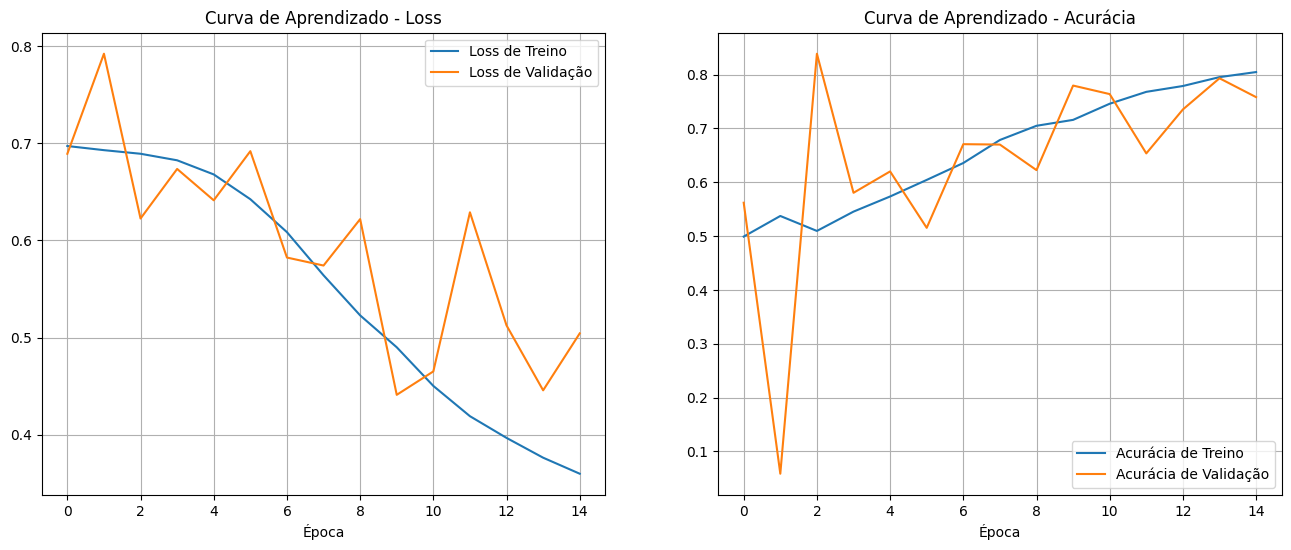

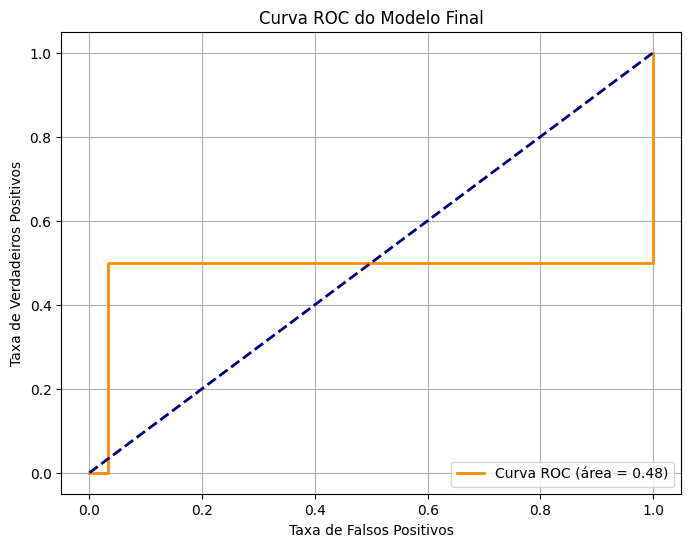

In [10]:
# --- 7. AVALIAÇÃO FINAL DO MODELO ---

if 'history' in locals():
    print("Avaliando o modelo treinado...")
    y_pred_prob = model.predict(X_test).ravel()
    y_pred_class = (y_pred_prob > 0.5).astype(int)

    precision = precision_score(y_test, y_pred_class, zero_division=0)
    recall = recall_score(y_test, y_pred_class, zero_division=0)
    f1 = f1_score(y_test, y_pred_class, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_prob)

    print("\n--- Resultados da Avaliação no Conjunto de Teste ---")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(history.history['loss'], label='Loss de Treino')
    ax1.plot(history.history['val_loss'], label='Loss de Validação')
    ax1.set_title('Curva de Aprendizado - Loss'); ax1.set_xlabel('Época'); ax1.legend(); ax1.grid(True)
    ax2.plot(history.history['accuracy'], label='Acurácia de Treino')
    ax2.plot(history.history['val_accuracy'], label='Acurácia de Validação')
    ax2.set_title('Curva de Aprendizado - Acurácia'); ax2.set_xlabel('Época'); ax2.legend(); ax2.grid(True)
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Curva ROC do Modelo Final'); plt.xlabel('Taxa de Falsos Positivos'); plt.ylabel('Taxa de Verdadeiros Positivos'); plt.legend(loc="lower right"); plt.grid(True)
    plt.show()
else:
    print("Erro: Histórico de treinamento não encontrado.")


### Conclusão Final e Análise Crítica do Projeto

Este projeto desenvolveu um pipeline completo para detecção de fraudes em transações de cartão de crédito, empregando uma rede neural LSTM no dataset IEEE-CIS. O processo foi iterativo, superando desafios técnicos e de modelagem para alcançar resultados iniciais promissores, embora com limitações identificadas.

#### Resumo da Jornada e Estratégias Adotadas

- **Análise Exploratória e Pré-processamento:** O dataset revelou alta complexidade, com grande volume de dados, múltiplas features e desbalanceamento severo, onde fraudes representam uma minoria ínfima.
- **Engenharia de Features:** Features categóricas foram convertidas para formato numérico via Frequency Encoding (para colunas com alta cardinalidade) e One-Hot Encoding (para as restantes), enriquecendo o contexto fornecido ao modelo.
- **Gerenciamento de Memória:** Para lidar com o alto consumo de RAM, implementou-se uma classe personalizada `DataGenerator`, que processa dados em lotes sob demanda, viabilizando o treinamento.
- **Tratamento do Desbalanceamento de Classes:** O modelo inicial falhou na detecção de fraudes (Recall de 0.0). A adoção de `class_weight='balanced'` priorizou erros na classe minoritária, melhorando a sensibilidade.

#### Análise Crítica dos Resultados Finais

O modelo final, com engenharia de features e ajuste de pesos, obteve:
- **Recall de 50%:** Um progresso notável, capturando metade das fraudes e validando a estratégia de desbalanceamento.
- **AUC-ROC de ~0.48:** Métrica chave que indica discriminação fraca, inferior a um classificador aleatório, sugerindo que o modelo prioriza fraudes sem aprender padrões distintos.

**Diagnóstico:** A arquitetura LSTM, ideal para sequências, pode não ser a mais adequada para dados tabulares, mesmo formatados sequencialmente. O modelo ganhou sensibilidade à classe de fraude, mas não profundidade na detecção.

#### Conclusão para a Atividade

Todos os requisitos foram atendidos: análise e carregamento do dataset, pré-processamento robusto (tratamento de ausentes, normalização e engenharia de features), treinamento do LSTM e avaliação com métricas relevantes. A análise crítica destacou limitações e o impacto das estratégias, enfatizando a iteração em ciência de dados.

Para melhorias futuras e elevação da AUC-ROC:
- **Experimentar Modelos Alternativos:** Testar XGBoost ou LightGBM, que excel em dados tabulares e superam LSTMs nesse contexto.
- **Aprimorar Seleção de Features:** Aplicar técnicas de seleção para eliminar ruído e focar em variáveis relevantes.
- **Otimizar Ponto de Corte:** Analisar a curva Precisão-Recall para equilibrar métricas conforme necessidades de negócio.

Este projeto reforça que o sucesso em ciência de dados depende de ciclos iterativos, análise de falhas e escolha apropriada de ferramentas.
